In [1]:
import numpy as np
import os
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

In [2]:
"""
Подготовка
"""

import kagglehub

path = kagglehub.dataset_download("balraj98/massachusetts-roads-dataset")
print("Path to dataset files:", path)

Path to dataset files: /home/f.danilov/.cache/kagglehub/datasets/balraj98/massachusetts-roads-dataset/versions/1


In [3]:
"""
Пути к папкам файлов
"""

TRAIN_DATA_PATH = path + '/tiff/train'
TRAIN_DATA_LABEL_PATH = path + '/tiff/train_labels'
VAL_DATA_PATH = path + '/tiff/val'
VAL_DATA_LABEL_PATH = path + '/tiff/val_labels'
TEST_DATA_PATH = path + '/tiff/test'
TEST_DATA_LABEL_PATH = path + '/tiff/test_labels'


### Augmentation & Normalize

In [4]:
import cv2

def enhance_contrast_clahe(image, **kwargs):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    enhanced = cv2.merge([l, a, b])
    return cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

In [ ]:
import albumentations as A

transform = A.Compose([
    A.Lambda(image=enhance_contrast_clahe, p=1.0),
    A.Resize(height=512, width=512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    A.ToTensorV2()
])


/home/f.danilov/workflow/.venv/lib/python3.10/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error _ssl.c:990: The handshake operation timed out>
  data = fetch_version_info()


### Class dataset with augmentation

In [6]:
class RoadDataset(Dataset):
    def __init__(self, path_dir_image, path_dir_label, dicrect_len, transforms=transform):
        self.samples = []
        self.direct_len = dicrect_len
        self.transforms = transforms
        
        image_list_path = os.listdir(path_dir_image)

        for idx, file in enumerate(image_list_path):
            if file.endswith('.tiff'):
                label_file_name = file.replace('.tiff', '.tif')
                full_image_path = os.path.join(path_dir_image, file)
                full_label_path = os.path.join(path_dir_label, label_file_name)
            
                if os.path.exists(full_label_path):
                    self.samples.append((full_image_path, full_label_path))
    
    def __len__(self):
        return self.direct_len
    
    def __getitem__(self, idx_phantom):
        idx_real = idx_phantom % len(self.samples)
        full_image_path, full_label_path = self.samples[idx_real]

        img = Image.open(full_image_path).convert('RGB')
        mask = Image.open(full_label_path)
        
        img = np.array(img)
        img = enhance_contrast_clahe(img)

        mask = np.array(mask)
        
        if mask.ndim == 3:
            mask = mask[:, :, 0]
        mask = (mask > 0).astype(np.float32)
        
        augmented = self.transforms(image=img, mask=mask)
        img = augmented['image']
        mask = augmented['mask'].long()
     
        return img, mask

### Datasets & Dataloaders

In [ ]:
train_dataset = RoadDataset(path_dir_image=TRAIN_DATA_PATH, path_dir_label=TRAIN_DATA_LABEL_PATH, dicrect_len=2400, transforms=transform)
val_dataset = RoadDataset(path_dir_image=VAL_DATA_PATH, path_dir_label=VAL_DATA_LABEL_PATH, dicrect_len=600, transforms=transform)
test_dataset = RoadDataset(path_dir_image=TEST_DATA_PATH, path_dir_label=TEST_DATA_LABEL_PATH, dicrect_len=1000,  transforms=transform)


train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,  
    shuffle=True,
    num_workers=2,  
    pin_memory=True,
    persistent_workers=False  
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False
)

print(f"Размер train: {len(train_dataset)}, {len(train_dataloader)}")
print(f"Размер valid: {len(val_dataset)}, {len(val_dataloader)}")
print(f"Размер test: {len(test_dataset)}, {len(test_dataloader)}")

img, label = train_dataset[1]
print(img.shape, label.shape)

Размер train: 2400, 75
Размер valid: 600, 75
Размер test: 1000, 250
torch.Size([3, 1024, 1024]) torch.Size([1024, 1024])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


float32 torch.int64


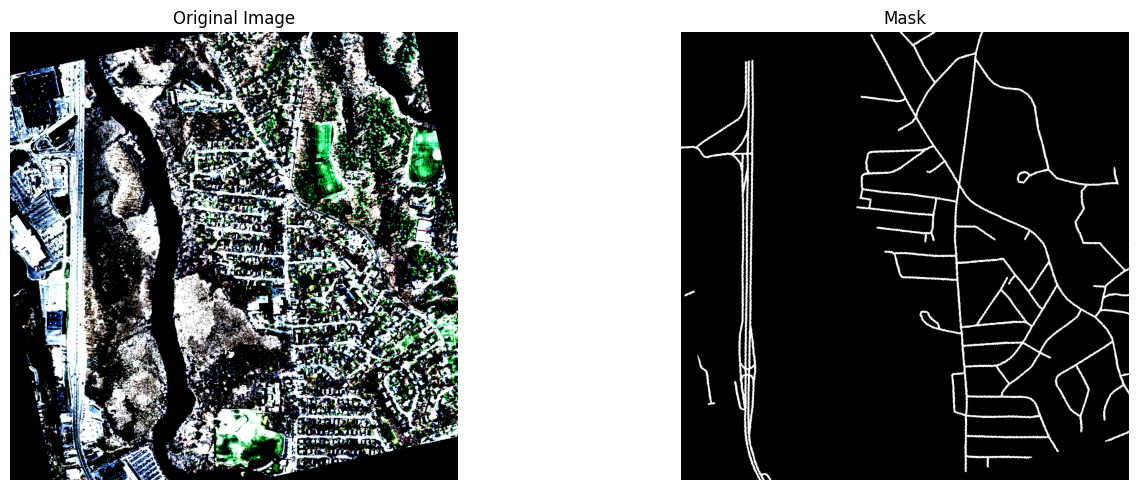

In [8]:
img_np = img.numpy()  # (3, 512, 512)
img_np = img_np.transpose(1, 2, 0)
mask_np = label.numpy()
print(img_np.dtype, label.dtype)
# Визуализируем
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
#img_np = img_np.clip(0,1)
axes[0].imshow(img_np)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(mask_np, cmap='gray')
axes[1].set_title('Mask')
axes[1].axis('off')

plt.tight_layout()
plt.show()




### Functions for saving weights of model and checkpoins of learning

In [9]:
def save_checkpoint(model, optimizer, train_losses=[], train_ious=[], val_losses=[], val_ious=[], epochs_list=[], filename='model/checkpoint.pth'):
    checkpoint = {
        'epoch': len(epochs_list),
        'epochs_list': epochs_list,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,  
        'train_ious': train_ious,         
        'val_losses': val_losses,
        'val_ious': val_ious
    }
    torch.save(checkpoint, filename)

def load_checkpoint(filename, model, optimizer, device):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    model.to(device)
    
    print(f"✓ Загружено из эпохи {checkpoint['epoch']}, Train Loss: {checkpoint['train_losses'][-1]:.4f}, Val Loss: {checkpoint['val_losses'][-1]:.4f}")
    print(f"Train IOU: {checkpoint['train_ious'][-1]:.4f}, Val IOU: {checkpoint['val_ious'][-1]:.4f}")
    return checkpoint['epoch'], checkpoint['train_losses'], checkpoint['train_ious'], checkpoint['val_losses'], checkpoint['val_ious'], checkpoint['epochs_list']

### Double Conv(U-net)

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):        
        return self.conv(x)

In [11]:
class MyUnet(nn.Module):
    def __init__(self):
        super().__init__()
        self.skip_connections = []
        
        self.skip1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.skip2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.skip3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.skip4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)   # 512 (апсемпл) + 512 (пропуск) = 1024
        
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)    # 256 (апсемпл) + 256 (пропуск) = 512
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)    # 128 (апсемпл) + 128 (пропуск) = 256
        
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)     # 64 (апсемпл) + 64 (пропуск) = 128
        
        self.final = nn.Conv2d(64, 1, kernel_size=1)

    
    def forward(self, x):
        # encoder
        enc1 = self.skip1(x)
        enc2 = self.skip2(self.pool1(enc1))
        enc3 = self.skip3(self.pool2(enc2))
        enc4 = self.skip4(self.pool3(enc3))
        
        bottleneck = self.bottleneck(self.pool4(enc4))
        
        # decoder со skip connections
        up4 = self.up4(bottleneck)
        up4 = torch.cat([up4, enc4], dim=1) # значения каналов суммируются (для использования деталей из encoder и семантическую)
        dec4 = self.dec4(up4)
        
        up3 = self.up3(dec4)
        up3 = torch.cat([up3, enc3], dim=1) # значения каналов суммируются (для использования деталей из encoder и семантическую)
        dec3 = self.dec3(up3)
        
        up2 = self.up2(dec3)
        up2 = torch.cat([up2, enc2], dim=1) # значения каналов суммируются (для использования деталей из encoder и семантическую)
        dec2 = self.dec2(up2)
        
        up1 = self.up1(dec2)
        up1 = torch.cat([up1, enc1], dim=1) # значения каналов суммируются (для использования деталей из encoder и семантическую)
        dec1 = self.dec1(up1)
        
        out = self.final(dec1)

        return out

In [12]:
from segmentation_models_pytorch.losses import DiceLoss

class CustomLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = DiceLoss(mode='binary', from_logits=True)
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, mask):
        bce_loss = self.bce(pred, mask.unsqueeze(1).float())
        dice_loss = self.dice(pred, mask)
        return bce_loss + dice_loss        

In [13]:
def binary_iou(preds, target, e=1e-6):
    preds = (preds > 0.5).float()

    if preds.dim() == 4 and preds.shape[1] == 1:
        preds = preds.squeeze(1)
    
    intersection = (preds * target).sum(dim=(1, 2))
    union = preds.sum(dim=(1, 2)) + target.sum(dim=(1, 2)) - intersection
    iou = intersection / (union + e)
    
    return iou.mean()

In [14]:
def train_step(model, optimizer, dataloader, criterion, device):
    model.train()
    running_loss = 0.
    running_iou = 0.

    for image, mask in dataloader:
        image = image.to(device)
        mask = mask.to(device)
        
        optimizer.zero_grad()
        outputs = model(image)
        
        loss = criterion(outputs, mask)
        iou = binary_iou(outputs, mask)

        loss.backward()
        optimizer.step()
        
        running_iou += iou
        running_loss += loss.item()

    train_iou = running_iou / len(dataloader)
    train_loss = running_loss / len(dataloader)
    return train_loss, train_iou

In [15]:
def validate(model, criterion, dataloader, device):
    model.eval()
    running_loss = 0.
    running_iou = 0.
    
    with torch.no_grad():
        for image, mask in dataloader:
            image = image.to(device)
            mask = mask.to(device)
            
            outputs = model(image)
            loss = criterion(outputs, mask)
            iou = binary_iou(outputs, mask)

            running_loss += loss.item()
            running_iou += iou
            
    val_iou = running_iou / len(dataloader)
    val_loss = running_loss / len(dataloader)
    return val_loss, val_iou

In [16]:
import segmentation_models_pytorch as smp

def train_system(train_dataloader, val_dataloader,  epochs=20, resume_from='model/checkpoint.pth'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on: {device}")
    
    #model = MyUnet().to(device)

    model = smp.Unet(
        encoder_name="resnet50",        
        encoder_weights="imagenet",     
        in_channels=3,
        classes=1,
        activation='sigmoid'            #бинарная сегментация
    ).to(device)

    for param in model.encoder.parameters():
        param.requires_grad = False

    criterion = CustomLoss()
    if torch.cuda.device_count() > 1:
        print("Avaible", torch.cuda.device_count(), "GPUs")
        model = nn.DataParallel(module=model)

    optimizer = torch.optim.AdamW(
        params=model.parameters(),
        lr=0.0005,
        weight_decay=1e-4, 
        betas=(0.9, 0.999)
    )
    
    train_losses = []
    val_losses = []
    train_ious = []
    val_ious = []
    best_loss = float('inf')
    start_epoch = 0
    epochs_list = []

    if resume_from and os.path.exists(resume_from):
        print(f"Продолжаем обучение из {resume_from}")
        start_epoch, train_losses, train_ious, val_losses, val_ious, epochs_list = load_checkpoint(resume_from, model, optimizer, device)
        start_epoch += 1
    
    for i in range(start_epoch, epochs):
        train_loss, train_iou = train_step(model, optimizer, train_dataloader, criterion, device)
        val_loss, val_iou = validate(model, criterion, val_dataloader, device)
        
        epochs_list.append(i)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_ious.append(train_iou)
        val_ious.append(val_iou)

        print(f"Epoch: {i+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        print(f"Train IOU: {train_iou:.4f}, Val IOU: {val_iou:.4f}\n")
        
        if (i + 1) % 5 == 0:
            save_checkpoint(model, optimizer, train_losses, train_ious, val_losses, val_ious, epochs_list)
        
        if val_loss < best_loss:
            best_loss = val_loss
            save_checkpoint(model, optimizer, train_losses, train_ious, val_losses, val_ious, epochs_list, 'model/checkpoint_best.pth')
            torch.save(model.state_dict(), 'model/model_best.pth')
    
    return train_losses, train_ious, val_losses, val_ious, epochs_list, model


## Обучение модели

In [17]:
train_losses, train_ious, val_losses, val_ious, epochs_list, model = train_system(train_dataloader, val_dataloader, epochs=50)

Training on: cuda
Avaible 4 GPUs


KeyboardInterrupt: 

#### График Loss и IOU

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

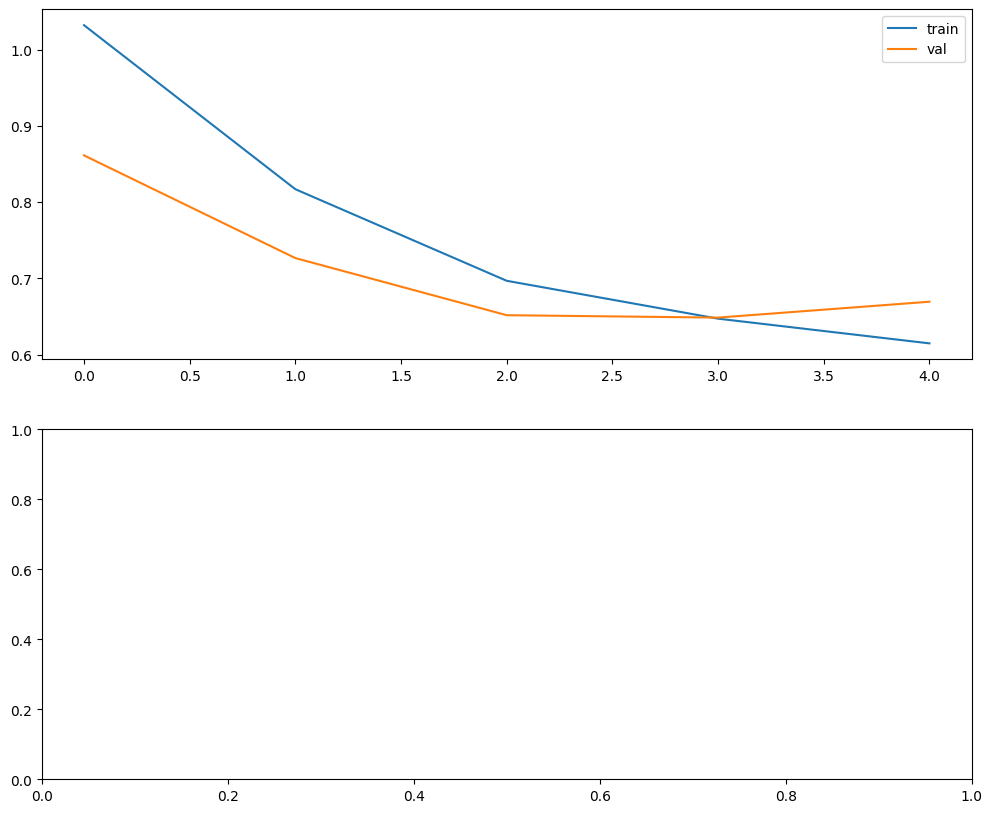

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

ax[0].plot(train_losses, label='train')
ax[0].plot(val_losses, label='val')
ax[0].legend()

ax[1].plot(train_ious, label='train')
ax[1].plot(val_ious, label='val')
ax[1].legend()

plt.tight_layout()
plt.show()